# Processamento de Linguagem Natural

## Análise de Linguagem Natural sobre os reviews de compradores do _dataset_ Olist

### Aluna: Renata Braga de Abreu

[Repositório GitHub](https://github.com/rabreu/Infnet-MIT-IA-PLN-PD_26E2_)

## Dependências

Antes de iniciar o projeto neste _notebook_, instalar as dependências contidas no _requirements.txt_.

> $ pip install -r ./requirements.txt

In [1]:
import re
from collections import Counter
from pathlib import Path

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sb
import spacy
from dotenv import load_dotenv
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
from nltk.metrics import edit_distance
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.naive_bayes import MultinomialNB
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings

warnings.filterwarnings("ignore")

## Preparação do ambiente

### Definição de variáveis para _download_ do _dataset_

In [2]:
DATASET_DIR = 'dataset'

ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = Path(ROOT_DIR).joinpath(DATASET_DIR)

load_dotenv(ROOT_DIR + 'secrets.env')

False

### Autenticação no Kaggle

In [3]:
!kaggle auth login

You are already logged-in to Kaggle as [renataabreu].
Please use the --force flag to override.


### Download do _dataset_ Olist

In [4]:
import kaggle

kaggle.api.authenticate()
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
kaggle.api.dataset_download_files('olistbr/brazilian-ecommerce', path=DATASET_PATH, unzip=True, quiet=False)

print("Path to dataset files: ", DATASET_PATH)

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


100%|██████████| 42.6M/42.6M [00:09<00:00, 4.73MB/s]



Path to dataset files:  C:\Users\Renata\DataspellProjects\Infnet-MIT-IA-PLN-PD_26E2_\dataset


## Normalização

In [5]:
reviews = pd.read_csv(DATASET_PATH.joinpath('olist_order_reviews_dataset.csv'), encoding='utf-8')
geolocation = pd.read_csv(DATASET_PATH.joinpath('olist_geolocation_dataset.csv'), encoding='utf-8')
reviews.dropna(axis=0, subset=['review_comment_message'], inplace=True)
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01
...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43


In [6]:
nltk.download('stopwords')

stop_words = stopwords.words('portuguese')
stop_words.extend(['nan', 'vcs', 'tbm', 'obg'])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Renata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Download das _stopwords_ na língua portuguesa.

In [7]:
def clean_text_as_list(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return [token for token in tokens if token not in stop_words]

def clean_text_as_str(text):
    tokens = simple_preprocess(str(text), deacc=True, min_len=3)
    return ' '.join((token for token in tokens if token not in stop_words))

Aplica a limpeza do texto com o retorno diferente para uso distintos (_list_ e _string_).

### Criação de novas colunas

In [8]:
cols = ['review_comment_title', 'review_comment_message']
reviews['tokens'] = (reviews[cols].astype(str)
                     .apply(lambda x:
                                                 ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) is not None else str(x['review_comment_message']))]), axis=1)
                     .apply(clean_text_as_list))

In [9]:
reviews['review_comment_transformed'] = (reviews[cols].astype(str)
                    .apply(lambda x:
                                ' '.join([str(x['review_comment_title']), str(x['review_comment_message'] if str(x['review_comment_title']) != 'nan' else str(x['review_comment_message']))]), axis=1
                            )
                    .apply(clean_text_as_str)
       )

| Nova coluna                  | Descrição                                                                                                    |
|------------------------------|--------------------------------------------------------------------------------------------------------------|
| _tokens_                     | aplica normalização e gera tokens a partir das colunas '_review_comment_title_' e '_review_comment_message_' |
| _review_comment_transformed_ | aplica normalização e união das colunas '_review_comment_title_' e '_review_comment_message_'                |

In [10]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,tokens,review_comment_transformed
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,"[recebi, bem, antes, prazo, estipulado]",recebi bem antes prazo estipulado
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,"[parabens, lojas, lannister, adorei, comprar, ...",parabens lojas lannister adorei comprar intern...
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47,"[recomendo, aparelho, eficiente, site, marca, ...",recomendo aparelho eficiente site marca aparel...
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,NaN,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16 00:00:00,2018-02-20 10:52:22,"[pouco, travando, valor, boa]",pouco travando valor boa
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23 00:00:00,2018-05-24 03:00:01,"[super, recomendo, vendedor, confiavel, produt...",super recomendo vendedor confiavel produto ent...
...,...,...,...,...,...,...,...,...,...
99205,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,NaN,para este produto recebi de acordo com a compr...,2017-11-29 00:00:00,2017-11-30 15:52:51,"[produto, recebi, acordo, compra, realizada]",produto recebi acordo compra realizada
99208,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,NaN,Entregou dentro do prazo. O produto chegou em ...,2018-02-07 00:00:00,2018-02-19 19:47:23,"[entregou, dentro, prazo, produto, chegou, con...",entregou dentro prazo produto chegou condicoes...
99215,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,NaN,"O produto não foi enviado com NF, não existe v...",2018-05-19 00:00:00,2018-05-20 21:51:06,"[produto, nao, enviado, nao, existe, venda, ce...",produto nao enviado nao existe venda certeza f...
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43,"[excelente, mochila, entrega, super, rapida, s...",excelente mochila entrega super rapida super r...


<Axes: >

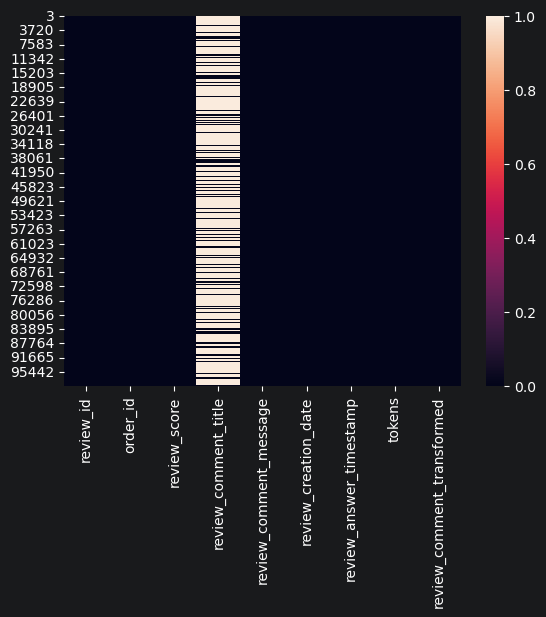

In [11]:
sb.heatmap(reviews.isna())

## Lematização / Stemming

In [12]:
!python -m spacy download pt_core_news_md

     ---------------------------------------- 0.0/42.4 MB ? eta -:--:--
     ---- ----------------------------------- 4.7/42.4 MB 25.9 MB/s eta 0:00:02
     -------- ------------------------------- 9.4/42.4 MB 25.6 MB/s eta 0:00:02
     ------------ -------------------------- 13.4/42.4 MB 23.3 MB/s eta 0:00:02
     -------------- ------------------------ 16.3/42.4 MB 20.9 MB/s eta 0:00:02
     ------------------ -------------------- 19.9/42.4 MB 20.3 MB/s eta 0:00:02
     -------------------- ------------------ 22.8/42.4 MB 19.2 MB/s eta 0:00:02
     --------------------- ----------------- 23.9/42.4 MB 17.2 MB/s eta 0:00:02
     ---------------------- ---------------- 24.9/42.4 MB 15.9 MB/s eta 0:00:02
     ----------------------- --------------- 26.0/42.4 MB 14.5 MB/s eta 0:00:02
     ------------------------- ------------- 27.8/42.4 MB 13.7 MB/s eta 0:00:02
     --------------------------- ----------- 29.4/42.4 MB 13.0 MB/s eta 0:00:01
     --------------------------- ----------- 30.

In [13]:
snowball_pt = SnowballStemmer(language="portuguese")
nlp_pt = spacy.load("pt_core_news_md")

tokens = []

docs = (reviews['review_comment_transformed'].astype(str)
                    .apply(clean_text_as_str)
       )

for doc in docs:
    lemanizer = nlp_pt(doc)
    for token in lemanizer:
        palavra = token.text.lower()
        stem = snowball_pt.stem(palavra)
        tokens.append({     'palavra': palavra,
                            'stemming': stem,
                            'lem': token.lemma_,
                            'classe': token.pos_})

In [14]:
nouns = pd.DataFrame(tokens)
nouns

,palavra,stemming,lem,classe
0,recebi,receb,recebi,VERB
1,bem,bem,bem,ADV
2,antes,antes,antes,ADV
3,prazo,praz,prazo,NOUN
4,estipulado,estipul,estipular,VERB
...,...,...,...,...
309657,pois,pois,pois,ADV
309658,defeito,defeit,defeito,NOUN
309659,nao,nao,nao,ADV
309660,segurar,segur,segurar,VERB


In [15]:
pd.DataFrame(Counter(nouns.palavra).most_common(10)).sort_values(by=1, ascending=False)

,0,1
0,produto,19616
1,nao,12917
2,prazo,8598
3,entrega,7010
4,recomendo,6064
5,antes,5680
6,chegou,5665
7,bom,5661
8,recebi,5545
9,entregue,3939


Palavras (_tokens_) com maiores frequências.

## Classificação

### Supervisionada com Naive Bayes e Vetorização com TfidfVectorizer

### Por Categorias

- 1 = Péssimo
- 2 = Ruim
- 3 = Regular
- 4 = Bom
- 5 = Excelente

In [16]:
categories = dict({
    1: 'Péssimo',
    2: 'Ruím',
    3: 'Regular',
    4: 'Bom',
    5: 'Excelente',
})

Neste caso, iremos usar as categorias como tokens e usa-los diretamente em nosso modelo.

In [17]:
model = MultinomialNB()
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(categories.values())

model.fit(X, list(categories.keys()))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [18]:
predictions_nm = []
rates_tf_idf = []
for review in docs:
    vec = vectorizer.transform([review])
    rates_tf_idf.append(model.predict(vec)[0])
    predictions_nm.append({"review": review, "nota": model.predict(vec)[0], "categoria": categories.get(model.predict(vec)[0])})

### Por _tokens_ (_input_ dos compradores)

Diferentemente do método anterior, aqui o será usado tokens gerados a partir dos reviews dos compradores e suas respectivas notas (1-5) serão suas categorias.

In [19]:
tokens_lem_by_rate = []
tokens_lem = []

_sample = pd.DataFrame(reviews).sample(frac=0.2, random_state=42) # Amostra de 20% dos reviews para gerar os tokens

for i, rate in enumerate(categories.keys()):
    filtered = _sample.query('review_score == ' + str(rate))
    for review in pd.DataFrame({'tokens': filtered.review_comment_transformed}).values:
        tokens = clean_text_as_str(review)
        lemanizer = nlp_pt(tokens)
        for lem in lemanizer:
            tokens_lem.append(lem.lemma_)
    tokens_lem_by_rate.append({'rate': rate, 'tokens': tokens_lem.copy()})
    tokens_lem.clear()

In [20]:
model_rate = MultinomialNB()
vectorizer_rate = TfidfVectorizer()

keys = list(pd.DataFrame(tokens_lem_by_rate)['rate'].apply(lambda x: str(x)))
values = list(pd.DataFrame(tokens_lem_by_rate)['tokens'].apply(lambda x: str(x)))
X_rate = vectorizer_rate.fit_transform(values)

model_rate.fit(X_rate, list(keys))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [21]:
predictions_nm_tokens = []
rates_tf_idf_tokens = []
for review in docs:
    vec = vectorizer_rate.transform([review])
    _X = model_rate.predict(vec)
    rates_tf_idf_tokens.append(int(_X[0]))
    predictions_nm_tokens.append({"review": review, "nota": _X[0], "categoria": categories.get(int(_X[0]))})

## VADER

O método VADER irá analisar o sentimento a partir de uma _tokenização_ manual levando em consideração a lexidade das sentenças.

In [22]:
analyzer = SentimentIntensityAnalyzer()

analyzer.lexicon.update({

    "excelente": 5,
    "qualidade": 5,
    "parabens": 5,
    "rapido": 5,
    "recomendar": 5,
    "resistente": 5,
    "otimo": 5,
    "super": 5,

    "bom": 4,
    "recebi": 4,
    "chegou": 4,
    "boa": 4,
    "obrigado": 4,
    "bonito": 4,

    "funcionar": 3,

    "muito ruim": 2,
    "ruim": 2,
    "mal": 2,
    "danificar": 2,
    "defeito": 2,
    "pequeno": 2,

    "pessimo": 1,
    "problema": 1,
    "horrivel": 1,
    "errar": 1,
    "retornar": 1,
    "cancelei": 1,
    "cancelar": 2,
    "reembolso": 1,
    "devolucao": 1,
    "devolver": 1,
})

In [23]:
def compound_to_rating(compound):
    if compound <= -0.6:
        return 1
    elif compound <= -0.2:
        return 2
    elif compound <= 0.2:
        return 3
    elif compound <= 0.6:
        return 4
    else:
        return 5

In [24]:
rates_vader = []
predictions_vader = []
for review in docs:
    vader = analyzer.polarity_scores(review)
    compound = vader['compound']
    rating = compound_to_rating(compound)
    rates_vader.append(rating)

    predictions_vader.append({"review": review, "nota": rating, "categoria": categories.get(rating)})


## Análise e Comparação

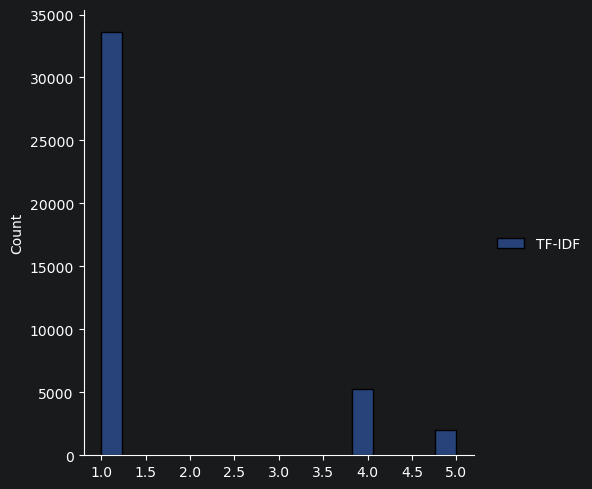

In [25]:
sb.displot(data=pd.DataFrame({'TF-IDF': rates_tf_idf}))

In [26]:
pd.DataFrame(predictions_nm)

,review,nota,categoria
0,recebi bem antes prazo estipulado,1,Péssimo
1,parabens lojas lannister adorei comprar intern...,1,Péssimo
2,recomendo aparelho eficiente site marca aparel...,1,Péssimo
3,pouco travando valor boa,1,Péssimo
4,super recomendo vendedor confiavel produto ent...,1,Péssimo
...,...,...,...
40972,produto recebi acordo compra realizada,1,Péssimo
40973,entregou dentro prazo produto chegou condicoes...,1,Péssimo
40974,produto nao enviado nao existe venda certeza f...,1,Péssimo
40975,excelente mochila entrega super rapida super r...,5,Excelente


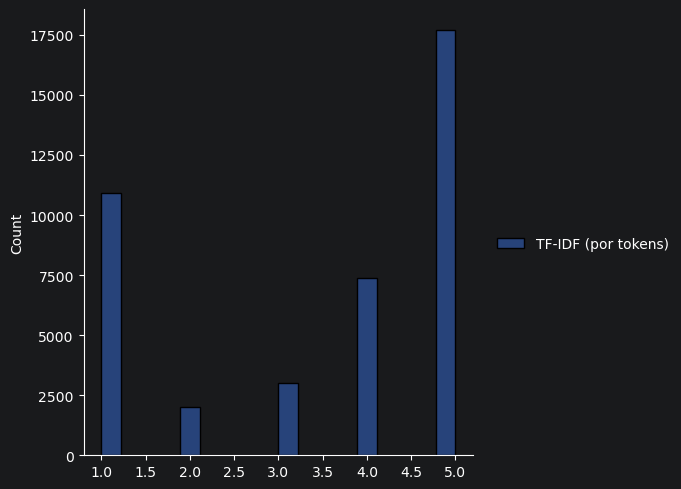

In [27]:
sb.displot(data=pd.DataFrame({'TF-IDF (por tokens)': rates_tf_idf_tokens}))

In [28]:
pd.DataFrame(predictions_nm_tokens).sample(frac=0.2)

,review,nota,categoria
30464,tudo certo,5,Excelente
36467,produto otima qualidade,4,Bom
51,super rapido entrega chegou antes data,5,Excelente
36074,nao vem nota fiscal porque,1,Péssimo
40881,produto acordo anuncio,4,Bom
...,...,...,...
2230,chegou antes prazo piso pratico facil montagem,5,Excelente
35585,super recomendo correspondeu expectativas bela...,5,Excelente
705,bom forma geral produto bom porem som sai baix...,4,Bom
9640,ainda aguardo produto,2,Ruím


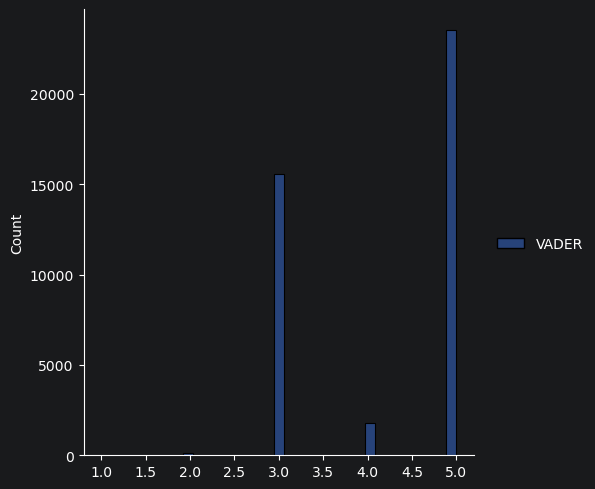

In [29]:
sb.displot(data=pd.DataFrame({'VADER': rates_vader}))

In [30]:
pd.DataFrame(predictions_vader).sample(frac=0.5)

,review,nota,categoria
18725,produto bom chegou bem rapido recomendo todos,5,Excelente
20338,excelente produto facil montagem pratico bonito,5,Excelente
2465,produto igual oferta porem xing ling veja nao ...,3,Regular
30451,bom produto produto entregue antes prazo encom...,5,Excelente
12022,rapidez qualidade havia solicitado cancelament...,5,Excelente
...,...,...,...
39107,excelente relogio recomendo,5,Excelente
2591,ruim nao recebi entrega completa entregaram ba...,5,Excelente
3566,recomendo comprei presente filha gostou produt...,5,Excelente
12652,veio errado,3,Regular


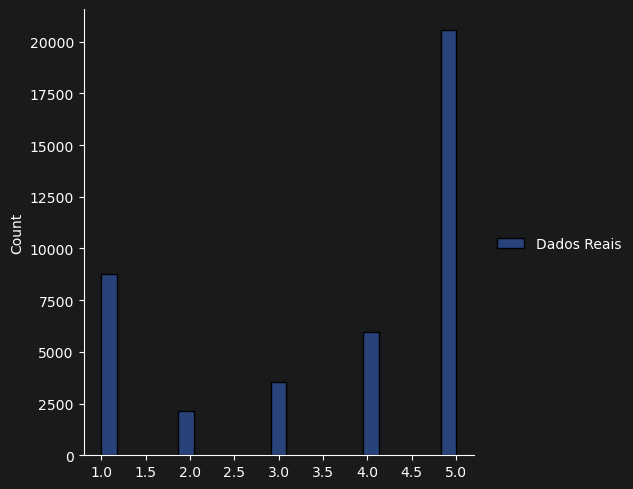

In [31]:
sb.displot(data=pd.DataFrame({'Dados Reais': reviews.review_score}))

| Método                                             | Análise                                                                                                                                                                                                                |
|----------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Naive Bayes / TF-IDF por Categoria                 | Não conseguiu categorizar, devido à falta de interpretação léxica e falta de variedade de tokens para categorizar.                                                                                                     |
| Naive Bayes / TF-IDF por Tokens (input de compradores) | Teve boa performance no treinamento, devido aos tokens serem coletados dos próprios compradores para realizar o treinamento, foi possível obter um resultado mais preciso, mesmo com ausência de interpretação léxica. |
| VADER                                              | Teve um desempenho médio, mesmo com a interpretação léxica. A falta de suporte nativo para a lingua portuguesa e a necessidade de input manual dos tokens é um desafio.                                                |

## Extração de Informação

### Por Regex

In [32]:
CPF_VALIDATION = "CPF (proibição)"
EMAIL_VALIDATION = "E-mail (proibição)"
PSEUDO_URL_VALIDATION = "Pseudo URL"
EXCESSIVE_REPETITION_VALIDATION = "Repetição excessiva"
RATE_IN_REVIEW_VALIDATION = 'Nota dentro do comentário'

matches = []
rules = []
all_matches = []
any_rule = False

for review in reviews.review_comment_message:
    cpf_validation = re.findall(r'/^\d{3}\.\d{3}\.\d{3}\-\d{2}$/', review)                          # Busca CPFs
    email_validation = re.findall(r'/^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$/', review)    # Busca e-mails
    excessive_repetition = re.findall(r'(.)\1{3}', review)                                          # Busca excesso de caracteres
    pseudo_url_validation = re.findall(r'\b\.(com|net|us)\b\s+', review)
    rate_in_review_validation_1 = re.findall(r'^[0-9]', review)                                     # Nota dentro do comentário 1
    rate_in_review_validation_2 = re.findall(r'\bnota\b\s+(\d+)', review, flags=re.IGNORECASE)      # Nota dentro do comentário 2

    if cpf_validation:
        any_rule = True
        matches.extend(cpf_validation)
        rules.append(CPF_VALIDATION)
    if email_validation:
        any_rule = True
        matches.extend(email_validation)
        rules.append(EMAIL_VALIDATION)
    if excessive_repetition:
        any_rule = True
        matches.extend(excessive_repetition)
        rules.append(EXCESSIVE_REPETITION_VALIDATION)
    if pseudo_url_validation:
        any_rule = True
        matches.extend(pseudo_url_validation)
        rules.append(PSEUDO_URL_VALIDATION)
    if rate_in_review_validation_1 or rate_in_review_validation_2:
        if rate_in_review_validation_1:
            matches.extend(rate_in_review_validation_1)
        if rate_in_review_validation_2:
            matches.extend(rate_in_review_validation_2)
        any_rule = True
        rules.append(RATE_IN_REVIEW_VALIDATION)

    if any_rule:
        all_matches.append({'review': review, 'match': matches.copy(), 'rules': rules.copy()})
        any_rule = False
        rules.clear()
        matches.clear()

In [33]:
pd.DataFrame(all_matches)

,review,match,rules
0,Loja nota 10,[10],[Nota dentro do comentário]
1,estao de parabens... sempre chega com muiiita ...,[.],[Repetição excessiva]
2,super rapido a entrega .... chegou antes da da...,[.],[Repetição excessiva]
3,Comprar um produto correto na capa mas interno...,[?],[Repetição excessiva]
4,Cada vez que compro mais fico satisfeita parab...,[👏],[Repetição excessiva]
...,...,...,...
1273,"O produto adquirido não pode ser utilizado, o ...",[.],[Repetição excessiva]
1274,Super recomendo!!!!!,[!],[Repetição excessiva]
1275,sim recebi na cor preta ....queria na cor verm...,[.],[Repetição excessiva]
1276,"Produto foi entregue em tempo ágil, super reco...",[.],[Repetição excessiva]


In [34]:
rule_counter = Counter()
for rules in pd.DataFrame(all_matches)['rules']:
    for rule in rules:
        rule_counter[rule] += 1

pd.DataFrame(rule_counter.most_common())
#
#

,0,1
0,Repetição excessiva,915
1,Nota dentro do comentário,309
2,Pseudo URL,68


### Por Spacy (entidades)

In [35]:
ents = []
for review in reviews.review_comment_message:
    doc = nlp_pt(review)
    if doc.ents:
        for ent in doc.ents:
            ents.append({'ent': ent.text.lower(), 'label': ent.label_})
#
#

In [36]:
ents = pd.DataFrame(ents)
pd.DataFrame(Counter([ent for ent in ents['label']]).most_common()).sort_values(by=1, ascending=False)

,0,1
0,MISC,5764
1,ORG,3542
2,LOC,3136
3,PER,2206


In [37]:
pd.DataFrame(Counter([ent for ent in ents['ent']]).most_common()).sort_values(by=1, ascending=False)

,0,1
0,produto,1225
1,recomendo,712
2,super,404
3,correios,203
4,recebi,192
...,...,...
5389,recevi,1
5390,propia americana,1
5391,maria cd,1
5392,bom diaa!!,1


### Levenshtein

In [39]:
from rapidfuzz.process import cdist
from rapidfuzz.distance import Levenshtein

freq = ents['ent'].value_counts().to_dict()
entities = list(freq.keys())
norm = [e.lower() for e in entities]

dist_matrix = cdist(norm, norm, scorer=Levenshtein.distance)

leven = {e: e for e in entities}

for i, e1 in enumerate(entities):
    for j in range(i + 1, len(entities)):
        if dist_matrix[i, j] <= 2:
            e2 = entities[j]
            if freq.get(leven[e2], 0) > freq.get(leven[e1], 0):
                leven[e1] = leven[e2]
            else:
                leven[e2] = leven[e1]

for e in leven:
    while leven[e] != leven[leven[e]]:
        leven[e] = leven[leven[e]]


Calcula a distância _levenshtein_ para filtrar similaridades.

In [40]:
pd.DataFrame(leven.keys()).sample(frac=0.1)

,0
1604,extraviado
5240,heineken
2237,fui atendido
848,brasilia
4384,e14
...,...
2998,correios odiei
4072,vendam
2758,eficiência
3230,poren


## Visualização

### t-TSNE

In [41]:
model_w2v = Word2Vec(
    sentences=[tokens for tokens in reviews.tokens],
    vector_size=100,
    window=5,
    min_count=5,
    workers=2
)

In [42]:
def plot_words_tsne(model, words):
    valid_words = [w for w in words if w in model.wv]
    word_vectors = np.array([model.wv[word] for word in valid_words])
    tsne = TSNE(n_components=2,
                perplexity=min(5, len(valid_words)-1),
                init='pca',
                random_state=0)
    word_vectors_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(15, 15))
    plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], edgecolors='k', c='g')
    for i, word in enumerate(valid_words):
        plt.annotate(word,
                     xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom')
        plt.title("Visualização t-SNE: Clusters Semânticos")
        plt.grid(True, linestyle='--', alpha=0.3)

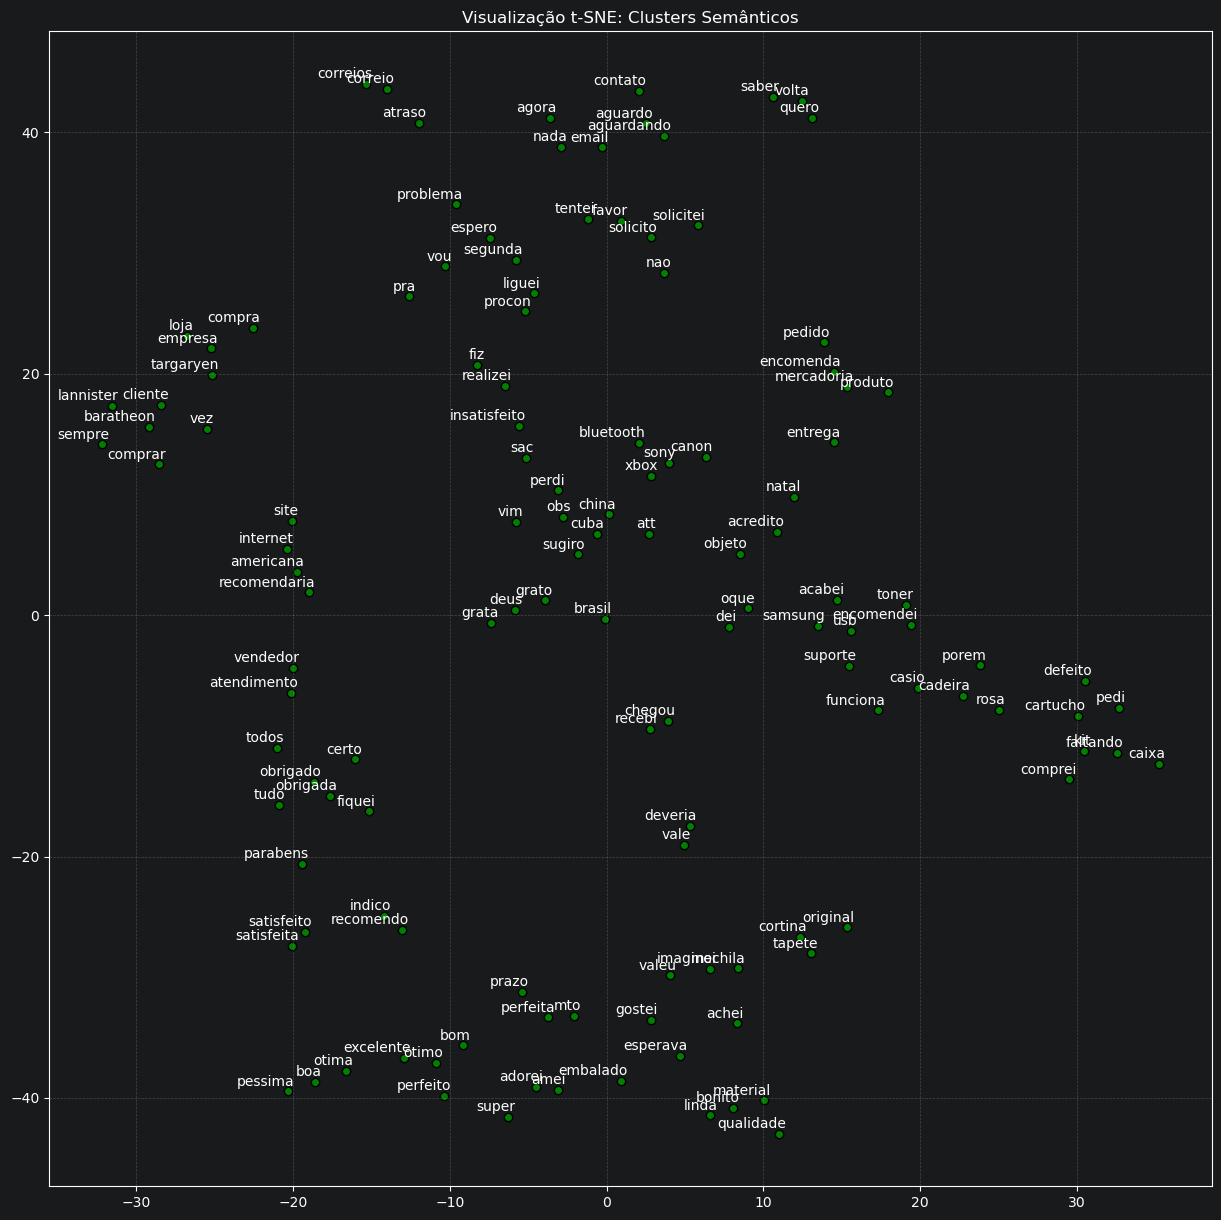

In [43]:
plot_words_tsne(model_w2v, [x[0] for x in Counter(list(leven.keys())).most_common(200)])

### Analises e conclusões

- Clientes insatisfeitos possivelmente acionaram o Procon.
- Atraso nos Correios pode ter causado insatisfação.
- Produtos da Sony, Canon e xBox possuem tecnologia Bluetooth.
- Os produtos são bem embalados.
- Cortinas, tapetes e mochilas possuem material de boa qualidade.
- Possível contato de compradores da Samsung com o Suporte.
- Cartuchos / Toners têm tendências a defeitos.

In [45]:
from gensim import corpora
from gensim.models import LdaModel

NUM_TOPICS = 5

dictionary = corpora.Dictionary(reviews.tokens)

corpus = [dictionary.doc2bow(text) for text in reviews.tokens]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=20,
    iterations=1000,
    alpha="auto",
    eta="auto",
    per_word_topics=True
)

In [63]:
def plot_wordcloud(topic_id, ax=None):
    topic_words = lda_model.show_topic(topic_id, topn=100)
    topic_words_dict = {word: freq for word, freq in topic_words}
    wc = WordCloud(
        background_color="white",
        width=800,
        height=600,
        collocations=False,
        prefer_horizontal=1
    )
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(wc.generate_from_frequencies(topic_words_dict))
    ax.axis("off")
    wc.generate_from_frequencies(topic_words_dict)
    return ax

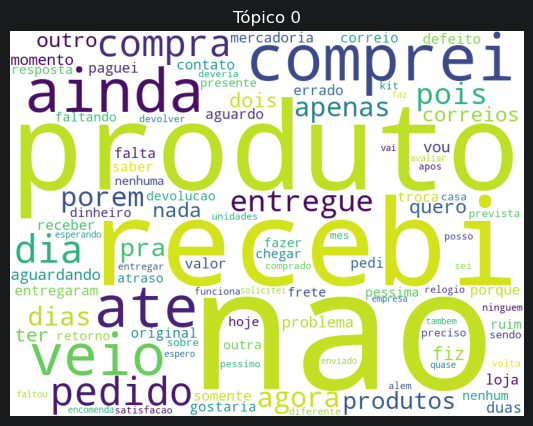

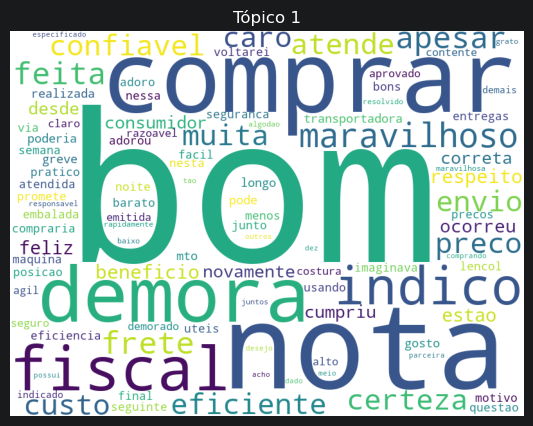

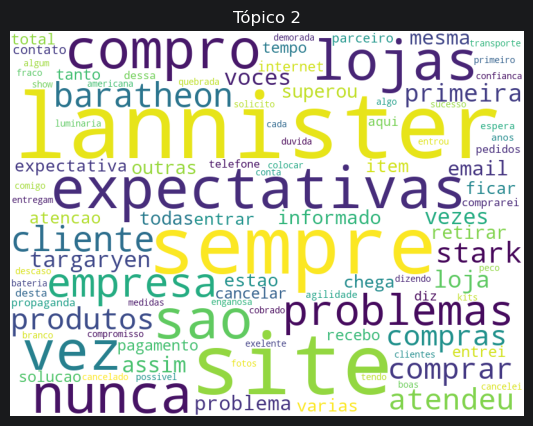

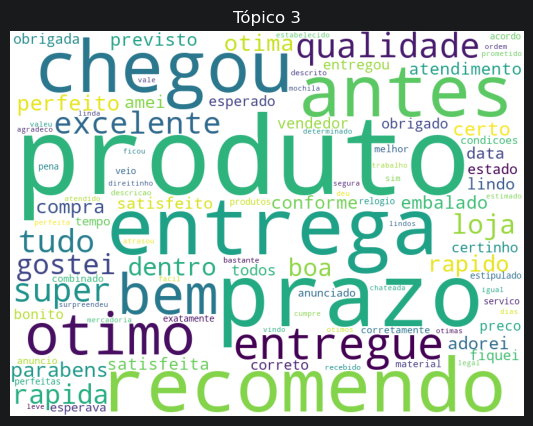

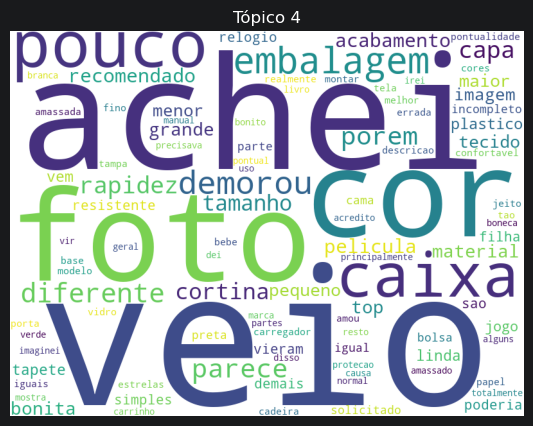

In [64]:
# clouds = []

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx in range(NUM_TOPICS):
    try:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        ax = plot_wordcloud(idx, ax)
        ax.set_title(f"Tópico {idx}")
        # clouds.append(fig)
    except:
        axes.flatten()[idx].remove()